# Разработка алгоритма BestNodeHalfDiameter

In [1]:
import networkx as nx
import osmnx as ox
import geopandas as gpd

from genesis.core import StateBase, MetricBase, BestPointsBase
from genesis.utils import timing

In [2]:
# Загрузка графа и полигона границ
G = ox.load_graphml("tests/data/test_rng.ml")
area = gpd.read_file("tests/data/test_polygon.gpkg")

In [95]:
class BestNodesHalfDiameter(BestPointsBase):
    '''
        Поиск лучших узлов графа с использованием алгоритма расчета точки в середине графа. 
        Могут быть возвращены только узлы из которых можно попасть в большую часть других узлов графа.
        Если таковых узлов нет, возвращается ошибка некорректности графа. 
        (граф должен быть проверен на корректность прежде чем будет передан функции)
        
        Узлы для которых метрика не может быть вычислена (например слабо связанные 
        с основным графом) не учитываются. 

        ## Область применения
        Определение размещения одного узла с наилучшими показателями. 
        Дает приближенное решение. Не рекомендуется к использованию как 
        самостоятельное решение. Однако может использоваться как способ
        ускорения работы других функций позволяющих искать размещение от
        стартового узла (BestNodeHillClimbing, BestNodeHillClimbing_maxMean и т.д.)
    '''
    def __init__(self,
                 state_function: StateBase = None,
                 metric_function: MetricBase = None,
                 weight: str = 'travel_time',
                 **kwargs) -> None:
        '''
        ## Аргументы
        `state_function`: StateBase
            функция расчета состояния окружения
        `metric_function`: MetricBase
            Функция расчета метрики
        `weight`:str или callable  = "travel_time"
            Имя поля содержащего вес ребер, или функция позволяющая вычислять 
            вес динамически.
        '''
        self.weight = weight
        super().__init__(state_function, metric_function, **kwargs)

    def __call__(self, env:nx.MultiDiGraph, **kwargs):
        '''
        ## Аргументы

        `env`:nx.MultiDiGraph
            Граф улично-дорожной сети
        '''
        # 1 Выбираем произвольную точку. По-умолчанию берем просто первую из списка узлов
        nd = list(env.nodes())[0]
        # 2 Находим самую отдаленную от нее (входящую) -- периферия №1
        lngs = nx.shortest_path_length(env, target=nd, weight=self.weight)
        corner_1 = max(lngs, key=lngs.get)
        # 2 Находим самую отдаленную от нее (входящую) -- периферия №2
        lngs = nx.shortest_path_length(env, target=corner_1, weight=self.weight)
        corner_2 = max(lngs, key=lngs.get)

        # Рассчитываем длину диаметра и маршрут следования по нему
        diameter = nx.shortest_path_length(env, corner_1, corner_2, weight=self.weight)
        short_path = nx.shortest_path(env, corner_1, corner_2, weight=self.weight)

        # Находим точку примерно по середине диаметра
        tot_len = 0
        for nd1, nd2 in zip(short_path[:-1],short_path[1:]):
            cur_len = env.get_edge_data(nd1, nd2, 0)[self.weight]
            tot_len += cur_len
            if tot_len >= diameter / 2: break

        return nd1

bnhd = timing(BestNodesHalfDiameter())
best_node = bnhd(env=G)
print(best_node)


ВРЕМЯ: 0.16 сек
4116048896


C:\Users\obsid\AppData\Local\Temp\ipykernel_2056\4045258174.py:8: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


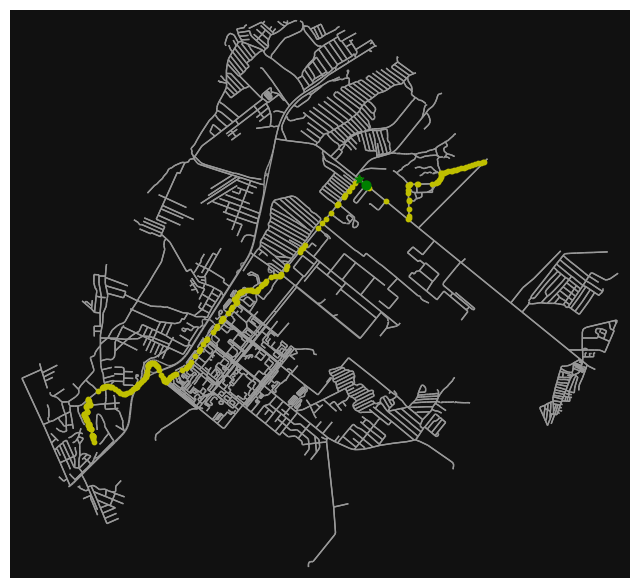

In [70]:
nodes = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, node_size=0, show=False)
nodes.loc[short_path].plot(ax=ax, markersize=10, color='y')
# nodes.loc[[10816267941,8089452663]].plot(ax=ax, markersize=40, color='r')
nodes.loc[best_node:best_node].plot(ax=ax, markersize=40, color='green', marker='*')
nodes.loc[4116048896:4116048896].plot(ax=ax, markersize=40, color='green')

fig.show()

In [74]:
diameter = nx.shortest_path_length(G, short_path[0], short_path[-1], weight='travel_time')
print(f'{diameter}')
tot_len = 0

for nd1, nd2 in zip(short_path[:-1],short_path[1:]):
    # print(nd1, nd2)
    cur_len = G.get_edge_data(nd1, nd2, 0)['travel_time']
    tot_len += cur_len
    # print(nd1, nd2, '\t', round(cur_len, 4), '\t', round(tot_len, 4))
    if tot_len >= diameter / 2: break

print('Answer', nd1)

30.991583857142857
Answer 4116048896


# Проверка другими алгоритмами

In [71]:
from genesis.best_points import BestNodesFull
from genesis.metrics import ArrivalTime
from genesis.states import FirstArrivalUnitState
from genesis.utils import Progressbar

pb = Progressbar(maxval=G.number_of_nodes(), bins=40)

bnf = BestNodesFull(FirstArrivalUnitState(), ArrivalTime())

best_node_bnf, best_metrc_bnf = bnf(G, node_calc_end_function=pb)
print(best_node_bnf, best_metrc_bnf)

|########################################| 100.0%
[426923808] 8.355415617070701


In [77]:
from genesis.best_points import BestNodeHillClimbing



bnhc = timing(BestNodeHillClimbing(FirstArrivalUnitState(), ArrivalTime()))

best_node_bnhc, best_metrc_bnhc  = bnhc(env=G)
print(best_node_bnhc, best_metrc_bnhc)

ВРЕМЯ: 5.13 сек
426923808 8.355415617070701


In [78]:
from genesis.best_points import BestNodeHillClimbing_maxMean

bnhmm  = timing(BestNodeHillClimbing_maxMean(FirstArrivalUnitState()))

best_node_bnhmm, best_metrc_bnhmm  = bnhmm(env=G)
print(best_node_bnhmm, best_metrc_bnhmm)

ВРЕМЯ: 5.28 сек
426923808 8.355415617070701


C:\Users\obsid\AppData\Local\Temp\ipykernel_2056\3611041490.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


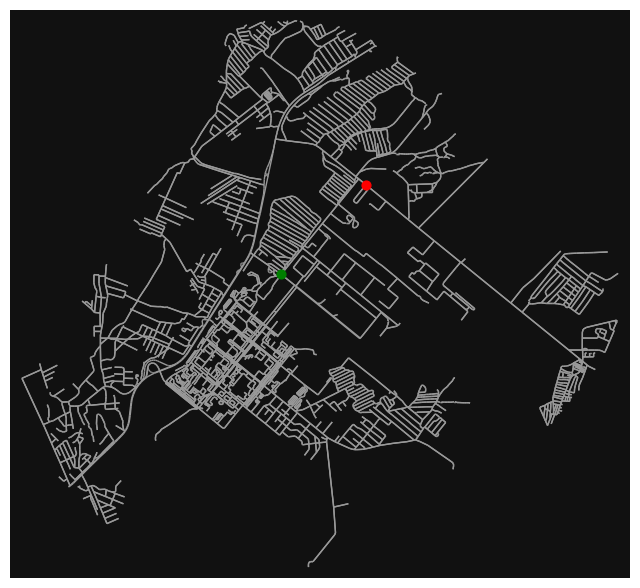

In [75]:
nodes = ox.graph_to_gdfs(G, edges=False)
fig, ax = ox.plot_graph(G, node_size=0, show=False)
nodes.loc[4116048896:4116048896].plot(ax=ax, markersize=40, color='red')
nodes.loc[best_node_bnhmm:best_node_bnhmm].plot(ax=ax, markersize=40, color='green')

fig.show()

### Проверка расчетом от точки центра диаметра

In [80]:
bnhd = timing(BestNodesHalfDiameter())
best_node_hd, _ = bnhd(env=G)

best_node_bnhc, best_metrc_bnhc  = bnhc(env=G, start_node=best_node_hd)
print(best_node_bnhc, best_metrc_bnhc)

best_node_bnhmm, best_metrc_bnhmm  = bnhmm(env=G, start_node=best_node_hd)
print(best_node_bnhmm, best_metrc_bnhmm)

10816267941 8089452663
30.991583857142857
ВРЕМЯ: 0.19 сек
ВРЕМЯ: 2.4 сек
426923808 8.355415617070701
ВРЕМЯ: 2.47 сек
426923808 8.355415617070701


т.е. Можно ускорить расчет в 2 раза!